In [13]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [2]:
data = load_iris()

In [32]:
x = pd.DataFrame(data.data,columns=data.feature_names)
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [33]:
out = []
for i in range(1,11):
    model = KMeans(n_clusters=i)
    model.fit(x)
    out.append(model.inertia_)

In [7]:
out

[681.3706,
 152.34795176035792,
 78.85566582597731,
 57.38387326549491,
 50.02042476002259,
 42.696490170940166,
 37.87730324250913,
 32.71713337831759,
 28.052316017316024,
 26.636586637047166]

In [12]:
from kneed import KneeLocator
k_values = range(1,11)
KL = KneeLocator(k_values,out,curve="convex",direction='decreasing')
k = KL.elbow
print("optimal value for k is: ",k)

optimal value for k is:  3


Text(0.5, 1.0, 'ELBOW curve')

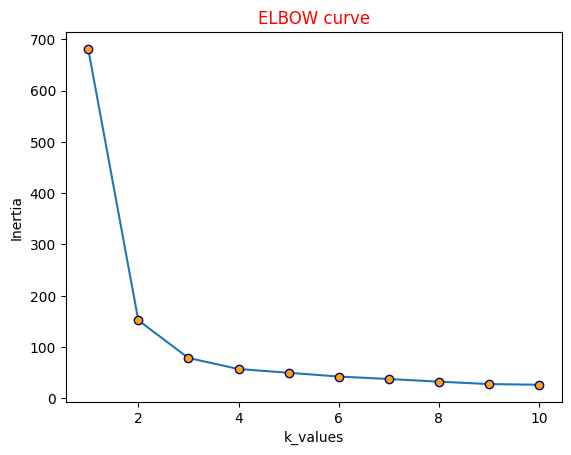

In [15]:
plt.plot(k_values,out,marker='o',markerfacecolor='orange',markeredgecolor="darkblue")
plt.xlabel('k_values')
plt.ylabel('Inertia')
plt.title('ELBOW curve',color='red')


In [16]:
model = KMeans(n_clusters=3)
model.fit(x)

KMeans(n_clusters=3)

In [19]:
labels = model.labels_
centroids = model.cluster_centers_
print(labels)
print(centroids)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]
[[5.006      3.428      1.462      0.246     ]
 [6.85384615 3.07692308 5.71538462 2.05384615]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


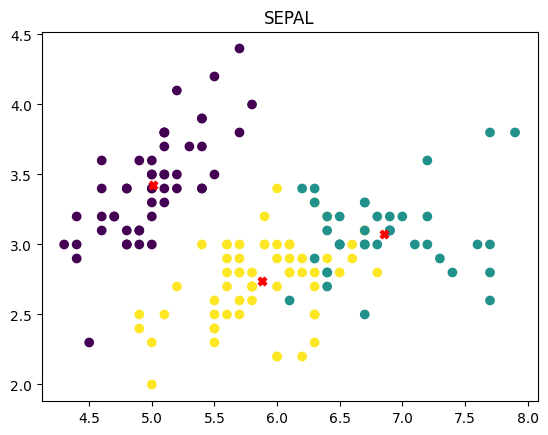

In [ ]:
plt.scatter(x['sepal length (cm)'],x['sepal width (cm)'],c=labels)
plt.scatter(centroids[:,0],centroids[:,1],marker="X",c='red')
plt.title("SEPAL")
plt.show()

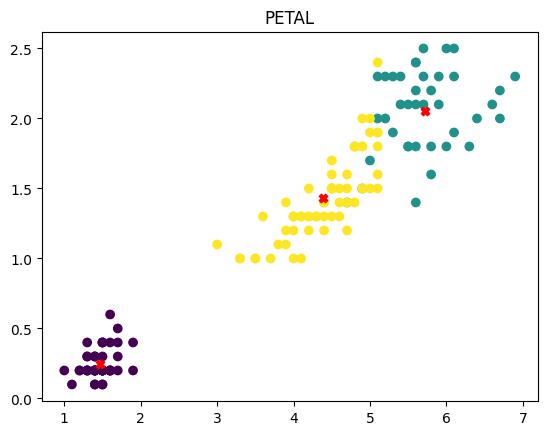

In [28]:
plt.scatter(x['petal length (cm)'],x['petal width (cm)'],c=labels)
plt.scatter(centroids[:,2],centroids[:,3],marker="X",c='red')
plt.title("PETAL")
plt.show()

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

array([[2, 3],
       [7, 8]])